# Haplosaurus

In [53]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('/grid/koo/home/schilder/projects/GenomeEncoder/')
import pandas as pd
import sys
sys.path.append("code")
import src.haplosaurus as hs
import src.variant_annotation as va
import src.ESM as ESM
import src.onekg as onekg
import src.utils as utils

import os
# os.chdir("/grid/koo/home/schilder/projects/GenomeEncoder/data")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# %%R

# db = EnsDb.Hsapiens.v86::EnsDb.Hsapiens.v86
# # get the transcript to protein ID mappings
# txs <- GenomicFeatures::transcripts(db, columns = c("tx_id","protein_id"))
# txs <- txs[!is.na(txs$protein_id)]
# data.table::fwrite(data.frame(txs), "data/bioc/bioc_tx_to_prot.csv.gz")

## Get transcripts

In [4]:
# hs_db = hs.get_figshare("haplotype_analysis_database.zip")
# #  List all files in the directory
# hs_db_files = [f"{hs_db}/{x}" for x in os.listdir(hs_db)]
# hs_db_sql = [x for x in hs_db_files if x.endswith(".sql.gz")][0]
# hs_db_files
# import mysql.connector
# conn = mysql.connector.connect(
# host="localhost",
# user="root",
# password="root",
# database="haplotype_analysis_database"
# )
# cursor = conn.cursor() 

In [5]:
# Haplosaurus protein IDs
tx_df = pd.read_excel("data/haplosaurus/41467_2018_6542_MOESM4_ESM.xlsx")
print(tx_df.shape)
# Bioconductor transcript to protein ID
tx_to_prot = pd.read_csv("data/bioc/bioc_tx_to_prot.csv.gz")
print(tx_to_prot.shape)
tx_df = tx_df.merge(tx_to_prot.drop_duplicates(subset=['tx_id', 'protein_id']),
                    left_on="Ensembl Protein ID", 
                    right_on="protein_id", 
                    how="inner") 
print(tx_df.shape)
tx_df.head()

(20166, 6)
(109705, 9)
(18494, 15)


/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3098: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Ensembl Gene ID,Ensembl Protein ID,Gene Name,Number of Haplotypes,Number of Haplotypes FoO>=1%,Frequency Rank of Reference Protein Haplotype,seqnames,start,end,width,strand,protein_id,uniprot_id,tx_biotype,tx_id
0,ENSG00000121410,ENSP00000263100,A1BG,44,3.0,2.0,19,58346850,58353499,6650,-,ENSP00000263100,P04217,protein_coding,ENST00000263100
1,ENSG00000148584,ENSP00000363107,A1CF,25,2.0,1.0,10,50806562,50885675,79114,-,ENSP00000363107,Q9NQ94,protein_coding,ENST00000373995
2,ENSG00000175899,ENSP00000323929,A2M,69,5.0,10.0,12,9067712,9116157,48446,-,ENSP00000323929,P01023,protein_coding,ENST00000318602
3,ENSG00000166535,ENSP00000299698,A2ML1,171,9.0,10.0,12,8822472,8876785,54314,+,ENSP00000299698,A8K2U0,protein_coding,ENST00000299698
4,ENSG00000184389,ENSP00000475261,A3GALT2,34,1.0,1.0,1,33306766,33321098,14333,-,ENSP00000475261,U3KPV4,protein_coding,ENST00000442999


<AxesSubplot:>

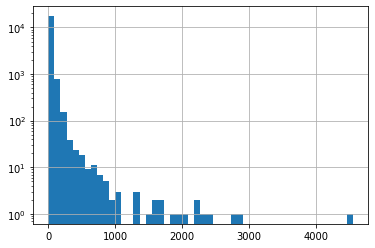

In [6]:
tx_df['Number of Haplotypes'].hist(bins=50, log=True)

In [7]:
# Remove MUC genes with lots of haplotypes as these may be artifacts
tx_df = tx_df[(tx_df['Number of Haplotypes'] > 50)]
# tx_df['Gene Name'].str.startswith('MUC')
tx_ids = list(set(tx_df['tx_id'].tolist()))
# tx_ids = tx_ids[:5]

print(len(tx_ids),"transcripts")

3401 transcripts


## Get variant sets
Collect sets of vairants (pathogenic, benign, 1KG) for each transcripts. 
Only trancripts with at least one pathogenic variant and one benign variant of the specifiied consequence type are included. Pathogenic/benign variants present in the 1KG cohort are excluded.

In [62]:
variant_sets = hs.get_variant_sets(
    tx_ids=tx_ids,
    so_term = 'SO:0001583',
    consequence_type = ['missense_variant'],
    save_dir="data/haplosaurus/variant_sets",
    save_dir_vep="data/haplosaurus/vep",
    cache_only=True, # Use cached files only (faster)
    force=True
    )

Gathering variant sets:   0%|          | 0/3401 [00:00<?, ?it/s]

ENST00000276297: Annotating pathogenic variants:   0%|          | 0/1 [00:00<?, ?it/s]

ENST00000276297: Filtering pathogenic variants:   0%|          | 0/1 [00:00<?, ?it/s]

ENST00000377403: Annotating pathogenic variants:   0%|          | 0/1 [00:00<?, ?it/s]

ENST00000377403: Filtering pathogenic variants:   0%|          | 0/1 [00:00<?, ?it/s]

...

ENST00000540549: Filtering pathogenic variants:   0%|          | 0/1 [00:00<?, ?it/s]

ENST00000327031: Annotating pathogenic variants:   0%|          | 0/2 [00:00<?, ?it/s]

ENST00000327031: Filtering pathogenic variants:   0%|          | 0/2 [00:00<?, ?it/s]

ENST00000360774: Annotating pathogenic variants:   0%|          | 0/2 [00:00<?, ?it/s]

ENST00000360774: Filtering pathogenic variants:   0%|          | 0/2 [00:00<?, ?it/s]

In [63]:
len(variant_sets)

416

## Get haplotypes


In [65]:
haplotypes = hs.get_haplotypes(
    tx_ids=variant_sets.keys(),
    save_dir="data/haplosaurus/haplotypes",
    species="homo_sapiens",
    params={'samples':1,
            'sequence':1,
            'aligned_sequences':1},
    cache_only=True, # Use cached files only (faster)
    force=False
    )


Getting haplotypes:   0%|          | 0/416 [00:00<?, ?it/s]

## Get reference haplotypes

In [66]:
haplotypes_ref = hs.get_haplotype_ref(haplotypes)
haplotypes_ref_seqs, missing_seqs = hs.get_haplotype_seqs(
    haplotypes_ref,
    return_missing=True,
    verbose=True)
(len(haplotypes), 
 len(haplotypes_ref), 
 len(haplotypes_ref_seqs),
 len(missing_seqs))


Processing transcripts:   0%|          | 0/382 [00:00<?, ?it/s]

  0%|          | 0/382 [00:00<?, ?it/s]

No seqs found for ENST00000354785
No seqs found for ENST00000324093
No seqs found for ENST00000405460


(382, 382, 379, 3)

## Add variants to haplotypes

In [67]:
haplotypes_wt, haplotypes_pathogenic, haplotypes_benign = hs.add_variant_to_haplotypes(
  haplotypes=haplotypes, 
  variant_sets=variant_sets, 
  max_transcripts=3,
  max_pathogenic_variants=1,
  max_benign_variants=1,
  ref_checks=False
  )


Adding variants to transcript haplotypes:   0%|          | 0/3 [00:00<?, ?it/s]

Getting pathogenic variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding pathogenic variants to haplotypes:   0%|          | 0/180 [00:00<?, ?it/s]

Getting benign variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding benign variants to haplotypes:   0%|          | 0/180 [00:00<?, ?it/s]

...

Adding benign variants to haplotypes:   0%|          | 0/109 [00:00<?, ?it/s]

Getting pathogenic variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding pathogenic variants to haplotypes:   0%|          | 0/381 [00:00<?, ?it/s]

Getting benign variant VEP:   0%|          | 0/1 [00:00<?, ?it/s]

Adding benign variants to haplotypes:   0%|          | 0/381 [00:00<?, ?it/s]

In [68]:
len(haplotypes_wt), len(haplotypes_pathogenic), len(haplotypes_benign)

(3, 3, 3)

## Get population frequencies

In [69]:
population_frequencies = hs.get_haplotype_freqs(haplotypes)
# population_frequencies[list(population_frequencies.keys())[0]]

  0%|          | 0/382 [00:00<?, ?it/s]

## ESM

In [70]:
# Check if GPU available
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.get_device_name(0))

False
0


RuntimeError: No CUDA GPUs are available

In [71]:
haplotypes_grouped = {'WT':haplotypes_wt, 
                     'Pathogenic':haplotypes_pathogenic, 
                     'Benign':haplotypes_benign
                     }
batches_grouped = {}
embeddings_grouped = {}
for group, haplotypes_group in haplotypes_grouped.items():
    batches_grouped[group] = hs.haplotypes_to_batches(haplotypes_group)

    embeddings_grouped[group] = ESM.get_embeddings(
        batches_grouped[group], 
        save_dir=f"data/1KG/embeddings/esm2_t33_650M_UR50D/{group}",
        desc=f"Embedding {group} transcript proteoforms",
        error=True,
        verbose=True
#         force=True
        )

Preparing batches for ESM


Preparing batches:   0%|          | 0/3 [00:00<?, ?it/s]

Using model: esm2_t33_650M_UR50D


Embedding WT transcript proteoforms:   0%|          | 0/3 [00:00<?, ?it/s]

In [109]:
for group, batches in batches_grouped.items():
    save_paths = ESM.get_embeddings(batches, 
                                    save_dir=f"data/1KG/embeddings/esm2_t33_650M_UR50D/{group}",
                                    error=True,
                                    force=True)
    seq_reps = ESM.get_representations(batches=batches, 
                                       save_paths=save_paths)

Found 1 ESM2 files


Extracting sequence representations:   0%|          | 0/1 [00:00<?, ?it/s]

In [110]:
(transcript_variances, 
 transcript_variance_means) = ESM.get_representation_variances(seq_reps)

transcript_variance_means

Computing transcript variances:   0%|          | 0/1 [00:00<?, ?it/s]

{'ENSP00000471493': tensor(8.1804e-06)}

In [111]:
X = ESM.get_representation_matrix(seq_reps, 
                                  save_path = "data/1KG/embeddings/esm2_t33_650M_UR50D/sequence_representation_matrix.pt")

Restructuring sequence representations into 2D array
torch.Size([88, 1280])


In [112]:
reducer, embedding, nan_indices = ESM.run_umap(X)

Filtering matrix
Matrix shape before filtering: torch.Size([88, 1280])
Matrix shape after filtering: torch.Size([88, 1280])
Running UMAP
UMAP( verbose=True)
Thu Jan  9 23:29:41 2025 Construct fuzzy simplicial set
Thu Jan  9 23:29:41 2025 Finding Nearest Neighbors
Thu Jan  9 23:29:41 2025 Finished Nearest Neighbor Search
Thu Jan  9 23:29:41 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Jan  9 23:29:42 2025 Finished embedding


In [113]:
embedding_df = ESM.get_umap_df(seq_reps, embedding, nan_indices) 

In [114]:
import numpy as np
for k in population_frequencies[list(population_frequencies.keys())[0]].keys():
    # Create list of frequencies, using 0 as default when key not found, NA for reference
    frequencies = [np.nan if 'reference' in x else population_frequencies[x].get(k, 0) for x in embedding_df['label']]
    embedding_df[f'freq_{k.strip("_")}'] = frequencies
embedding_df.head()

,UMAP 1,UMAP 2,label,transcript_id,transcript,freq_1000GENOMES:phase_3:JPT,freq_1000GENOMES:phase_3:GIH,freq_1000GENOMES:phase_3:CLM,freq_1000GENOMES:phase_3:MSL,freq_1000GENOMES:phase_3:ESN,...,freq_1000GENOMES:phase_3:AFR,freq_all,freq_1000GENOMES:phase_3:GWD,freq_1000GENOMES:phase_3:EUR,freq_1000GENOMES:phase_3:PJL,freq_1000GENOMES:phase_3:PUR,freq_1000GENOMES:phase_3:CHS,freq_1000GENOMES:phase_3:CHB,freq_1000GENOMES:phase_3:KHV,freq_1000GENOMES:phase_3:YRI
0,2.690313,11.386104,"ENSP00000471493:11I>T,192N>K,346E>A",ENSP00000471493,ENSP00000471493,0.134615,0.242718,0.218085,0.152941,0.272727,...,0.226172,0.166500,0.185841,0.261431,0.229167,0.153846,0.114286,0.140777,0.101010,0.222222
1,3.681312,11.953553,"ENSP00000471493:11I>T,346E>A",ENSP00000471493,ENSP00000471493,0.120192,0.087379,0.085106,0.176471,0.131313,...,0.167927,0.156863,0.168142,0.067594,0.109375,0.096154,0.104762,0.116505,0.075758,0.236111
2,4.231814,12.139377,"ENSP00000471493:11I>T,101V>L,346E>A",ENSP00000471493,ENSP00000471493,0.072115,0.101942,0.212766,0.052941,0.040404,...,0.045386,0.127119,0.030973,0.128231,0.114583,0.129808,0.180952,0.097087,0.126263,0.037037
3,3.505685,13.675764,ENSP00000471493:11I>T,ENSP00000471493,ENSP00000471493,0.100962,0.097087,0.069149,0.111765,0.116162,...,0.119516,0.101030,0.110619,0.072565,0.104167,0.091346,0.133333,0.140777,0.126263,0.148148
4,2.787711,11.735064,"ENSP00000471493:11I>T,101V>L,192N>K,346E>A",ENSP00000471493,ENSP00000471493,0.096154,0.077670,0.037234,0.141176,0.126263,...,0.115734,0.073446,0.128319,0.052684,0.093750,0.120192,0.057143,0.053398,0.106061,0.087963


In [156]:
# Add a new column with the population in which the variant is most common
pops = population_frequencies[list(population_frequencies.keys())[0]].keys()
freq_cols = [f'freq_{p}' for p in pops if f'freq_{p}' in embedding_df.columns]
embedding_df['top_pop'] = 'reference'
if freq_cols:
    max_freq_idx = embedding_df[freq_cols].idxmax(axis=1)
    embedding_df.loc[~embedding_df[freq_cols].isna().all(axis=1), 'top_pop'] = max_freq_idx.str.replace('freq_', '').str.replace('1000GENOMES:phase_3:', '')
embedding_df.top_pop.value_counts()

JPT    11
GWD     7
CHB     7
LWK     6
CDX     5
YRI     5
MSL     5
PEL     5
ACB     5
ESN     4
KHV     4
ITU     4
ASW     3
STU     3
IBS     3
CEU     3
PUR     3
CLM     1
MXL     1
GBR     1
CHS     1
GIH     1
Name: top_pop, dtype: int64

In [159]:
pops = onekg.get_sample_metadata()
pop_map = dict(zip(pops['Population Code'], pops['Super Population']))
print(pop_map)
embedding_df['top_pop_super'] = embedding_df['top_pop'].map(pop_map)
embedding_df.value_counts('top_pop_super')


{'GBR': 'EUR', 'FIN': 'EUR', 'CHS': 'EAS', 'PUR': 'AMR', 'CDX': 'EAS', 'CLM': 'AMR', 'IBS': 'EUR', 'PEL': 'AMR', 'PJL': 'SAS', 'KHV': 'EAS', 'ACB': 'AFR', 'GWD': 'AFR', 'ESN': 'AFR', 'BEB': 'SAS', 'MSL': 'AFR', 'STU': 'SAS', 'ITU': 'SAS', 'CEU': 'EUR', 'YRI': 'AFR', 'CHB': 'EAS', 'JPT': 'EAS', 'LWK': 'AFR', 'ASW': 'AFR', 'MXL': 'AMR', 'TSI': 'EUR', 'GIH': 'SAS'}


top_pop_super
AFR    35
EAS    28
AMR    10
SAS     8
EUR     7
dtype: int64

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

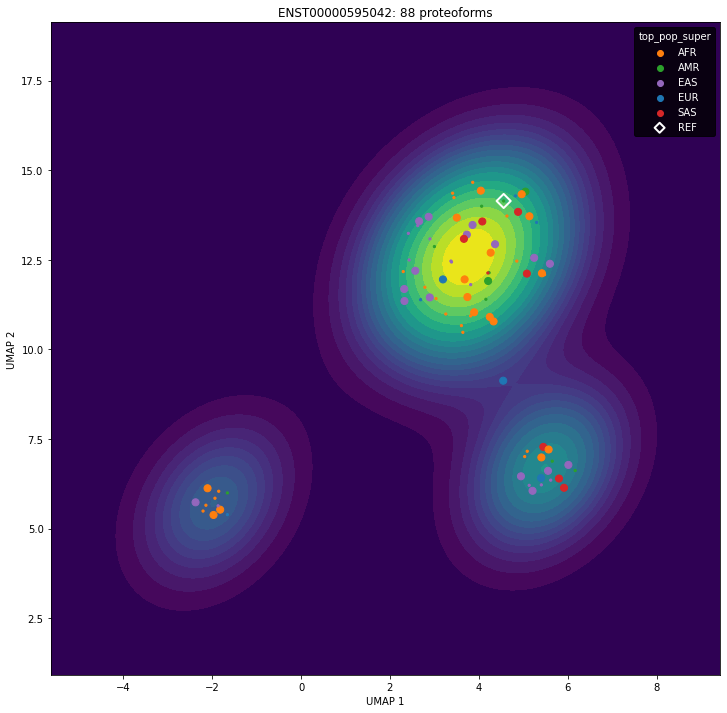

In [196]:
ESM.plot_umap(embedding_df,
        #   facet_col="transcript_id",
          title=f"{tx_id}: {embedding_df.shape[0]} proteoforms",
          highlight_label="REF",
          opacity=1,
          size="freq_all",
          sizes=(5,50),
          color_col="top_pop_super",
#           bw_adjust=0.5, # Decrease bandwidth for higher granularity 
          levels=20, # Increase number of contour levels
          thresh=0.05 # Lower threshold to show more detail
          )